In [1]:
import geopandas as gpd
import sys
from pathlib import Path
path = Path().cwd().parent / "src" #to add the src directory to the path regognized by Python
sys.path.append(str(path))
import methods_two_point_correlation as mtpc
import save_load_pickle as slp
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial import distance
import matplotlib.pyplot as plt
import sklearn.cluster as sk
import sys
from sklearn.metrics import silhouette_score
from shapely.geometry import Polygon,Point
from scipy.stats import entropy

# Parameters

In [2]:
#set paths
path = Path().cwd().parent
sys.path.append(str(path))
data_dir = path/"data/cities"
map_dir = path/"data/map"
plot_dir = path/"out/plot_fitted_parameters/"

In [3]:
name = "Belgium" #name of country
nbins=30 # number of bins to make for every binning operation
out_dir = path /Path(f"out/2pcf/{name}")
file = out_dir / f"1_5_7000_3__100000.0_log_{nbins}" #name of dataset

diminish_radius = 1 # multiplication factor for the maximum radius, 
#to be lowered if the SP does not fit inside the considered border quick enough

N_run= 3 # number of random catalog generated for computing the 2PCF, needs to be the same as in the plotted data
size= 3000 #number of points each random catalog has
erase_nodes = False

In [4]:
#Load the polygon file for border
path_border = Path.cwd() / map_dir / f"{name}.geojson"
gdf_edge = gpd.read_file(path_border)

#load the results store in file
dico_results = slp.load_results(file)
r_edges = dico_results["r_edges"] #binning of distance for 2pcf
gamma, r0 = dico_results["fit_SP"] #fitted gamma and R0
l_xi = dico_results["xi"] # 2pcf
country_distribution = dico_results["distance_distribution"] #distance distribution
l_cluster = dico_results["clustering"] #5 best cluster value obtained with the silhouette score
N = dico_results["number_points"] #number of point sin the dataset
crs = mtpc.crs_selector(name) #cooridnate reference system associated with the datset
gdf_edge = gdf_edge.to_crs(crs) # Polygon of the border of the country

eta = l_cluster[0] #density, number of circles by steps
l = eta**(1/(2-gamma)) #fraction of space covered by the circles
L = int(np.log(N)/np.log(eta)+1)-1 #size of circles, number of steps
R = 0.5*gdf_edge.length[0]/(2*np.pi)*diminish_radius # radius max
min_rad = R/(l**(L-1))

rmin= np.min(r_edges)
rmax= np.max(r_edges)
k = N_run
scale="log"

In [5]:
print("gamma", gamma)
print("fractal dimension",np.log(eta)/np.log(l))
print("l = ", l)
print("L = ", L)

gamma 0.6724818139619436
fractal dimension 1.3275181860380565
l =  1.685627024211333
L =  9


In [6]:
dico_results

{'r_edges': array([  3579.20107024,   4014.72258873,   4503.23889274,   5051.19845192,
          5665.83439352,   6355.25998044,   7128.57570726,   7995.98942774,
          8968.95109964,  10060.30392545,  11284.45388408,  12657.55989139,
         14197.74709967,  15925.34615169,  17863.16154745,  20036.77266609,
         22474.87141659,  25209.64097412,  28277.18060157,  31717.98216383,
         35577.46462494,  39906.57358342,  44762.45375992,  50209.20331385,
         56318.71994624,  63171.64995741,  70858.45278712,  79480.59508925,
         89151.89010293, 100000.        ]),
 'xi': array([[ 0.20426935,  0.98394861,  0.24638902,  0.26794562,  0.50842757,
          0.74822644,  0.1809176 ,  0.53783681,  0.30754255,  0.44927189,
          0.2832859 ,  0.24873806,  0.33417227,  0.18383534,  0.24986574,
          0.26823848,  0.21844225,  0.21318139,  0.16328831,  0.13507687,
          0.15216161,  0.13574661,  0.13696144,  0.09909736,  0.11435199,
          0.08179384,  0.07894132,  0

In [7]:
np.sqrt(np.diag(dico_results["covariance_fit"]))

array([1.06122379e-01, 5.08884924e+02])

# Select the best combination of parameters
## Select the best combination of eta, L and number of random points to fit the synthetic 2pcf to the empirical one

In [8]:
def check_inside(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles that fit the border defined by gdf_edge
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
    """
    position,point_outside = soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    while len(point_outside) >= 1: #as long as not all the points fit hte border redo
        #print("Entering the loop")
        position,point_outside=soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    return position


def soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
        points_outside: count the number of points that lie outside of the border as defined by gdf_edge
    """
    position = gdf_edge.centroid.get_coordinates().to_numpy()
    final_position = []
    rng = np.random.default_rng()
    for i in range(L):
        l_pos = []
        for x,y in position:
            r = (R/(lamb**i))*np.random.uniform(low=0, high=1, size=eta)  # radius
            theta = np.random.uniform(low=0, high=2*np.pi, size=eta)  # angle
            l_x_rand = [r[i] * np.cos(theta[i]) for i in range(eta)]
            l_y_rand = [r[i] * np.sin(theta[i]) for i in range(eta)]
            l_point = [Point((x_rand,y_rand)) for x_rand,y_rand in zip(l_x_rand,l_y_rand)] 
            #l_random = (R/(lamb**i))*rng.random((eta,2))
            for x_rand,y_rand in zip(l_x_rand,l_y_rand):
                #s = geopandas.GeoSeries(point)
                l_pos.append((x-x_rand,y-y_rand))
        position = np.copy(l_pos)
        final_position = final_position + l_pos
    if type(erase_nodes) == int and erase_nodes >=0:
        print("enter erase")
        position = list(position)
        while erase_nodes != 0:
            index = rng.choice(range(len(position)))
            position.pop(index)
            erase_nodes -= 1
    position = np.array(position)
    #l_point = [Point(position[i]) for i in range(len(position))]
    s = gpd.GeoDataFrame(
          position, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    points_with_join = gpd.sjoin(s, gdf_edge, how="left", predicate="within")
    points_with_join['is_inside'] = points_with_join['index_right'].notna()
    point_outside = points_with_join[points_with_join["is_inside"] == False]
    return position,point_outside

def plot_two_2pcf(r_edges,l_xi,l_xi_SP):
    fig, ax = plt.subplots()
    sns.set(style="whitegrid")
    xi = np.mean(l_xi,axis=0)
    error = np.std(l_xi,axis=0)
    xi_SP = np.mean(l_xi_SP,axis=0)
    error = np.std(l_xi,axis=0)
    if len(xi) != len(r_edges): #when we choose a rmax define by user the code put an extra category above
        xi = xi[0:-1]
        error = error[0:-1]
        xi_SP = xi_SP[0:-1]
    color = sns.color_palette("viridis")[0]
    color_SP = sns.color_palette("viridis")[1]
    r_edges = r_edges[1:]
    xi = xi[1:]
    xi_SP = xi_SP[1:]
    error = error[1:]
    end = np.zeros([1])
    end[0] = 1.1*r_edges[-1]
    r_edges_zero = np.concatenate((r_edges,end))
    width = np.diff(r_edges_zero) #need to find a way to encode properly the first alignement
    ax.bar(r_edges,xi,width=width,align="center",edgecolor="black",color=color,alpha=0.5,label=f"{name}")
    ax.bar(r_edges,xi_SP,width=width,align="center",edgecolor="black",color=color_SP,alpha=0.5,label="SP")
    plt.errorbar(r_edges, xi, yerr=error, fmt="o", color="r",ms=1)
    title = "2 points correlation function "+name
    plt.title(title)
    plt.ylabel(r"$\xi(r)$")
    plt.xlabel(r"$r$ (meters)")
    plt.xscale("log")
    #plt.yscale("log")
    plt.legend()
    #plt.savefig(plot_dir / title, format="png",transparent=True)
    plt.show()

In [9]:
 """ Find the good paraemter L (number of steps) and the number of random nodes 
 needed to fit the 2pcf of the model (l_xi_random_SP) to the empirical 2pcf (l_xi)
Input:
    l_xi_random_SP: 2pcf of the original Soneira-Peebles without random point
    l_xi: 2pcf of the empirical system
    N: Number of points in the empirical system
    eta: number of points per step
Output:
    L: number of steps required  for the 2pcf of the SOneira-Peebles to fit the empircial one
    Nr: number of random points to add to the eta**L points of the Soneira-Peebles """

def find_good_L(l,eta,L,R,gdf_edge,l_xi,N,iteration_pure_SP):
    l_alpha = []
    for i in range(iteration_pure_SP): # number of time we retry the 
        position = check_inside(l,eta,L,R,gdf_edge) #1st position for reference ie. the SP without random points
        position[-1] = [0,0] # trick to allow that the binning is done correctly for all datasets
        random_point = 0
        r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax=rmax)
        ratio = np.abs([l_xi_random_SP[i]/l_xi[i] for i in range(len(l_xi))])
        l_alpha.append(1/np.mean(ratio))
    print(np.mean(l_alpha))
    print(l_alpha)
    alpha = np.mean(l_alpha)
    ratio = (1/np.sqrt(alpha)-1) #ratio of number of random points needed over the number of points from the SP model
    N_model = 1e-10
    #l_ratio = []
    #current_ratio= (N-N_model)/(N_model)
    #l_ratio.append(np.abs(ratio-current_ratio))
    i =0
    Nr=1e-10
    while N_model+Nr < N:
        i+=1
        N_model = eta**i
        Nr = int(ratio*N_model)
        #current_ratio= (N-N_model)/(N_model)
        #l_ratio.append(np.abs(ratio-current_ratio))
    L = i
    print(N_model,Nr,L)
    return L,Nr
    
 """ Make the 2pcf of the model (l_xi_random_SP) Soneira-Peebles + random
Input:
    position: Array of coordinates of points
    random_point: number of random points to add to the eta**L points of the Soneira-Peebles
    rmax: Number of points in the empirical system
Output:
    L: number of steps required  for the 2pcf of the SOneira-Peebles to fit the empircial one
    Nr: number of random points to add to the eta**L points of the Soneira-Peebles"""
def make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax):
    d = {}
    d["x"] = position.T[0]
    d["y"] = position.T[1]
    gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    if random_point != 0:
        gdf_random_square = gdf_edge.sample_points(random_point)
        gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
        gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
    #print(len(gdf))
    r_edges_random_SP,l_xi_random_SP = mtpc.PCF_with_variance(gdf,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins,rmin=rmin)
    # Compute the 2 pcf with variance
    return r_edges_random_SP,l_xi_random_SP

In [10]:
 """ Find the parameters that best fit the 2pcf of the empirical system
Input:
    l_cluster: Array of coordinates of points
    number_of_try_for_each_parameter: several try for agiven paraemter set for the try of teh cost fucntion
    rmax: ramx in the system
Output:
    save_dist: for each eta and best try, store the cost function (euclidean distance)
    save_L: save the L that were tried, save_L[np.argmin(save_dist)] give teh best L of all
    save_random: save the number of random points that were tried, save_random[np.argmin(save_dist)] give teh best number of random points of all
    """
def find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter,iteration_pure_SP):
    save_dist = []
    save_L = [] #save best value of L for given eta (index)
    save_random = [] #save best valeur of random point for given eta (index)
    erase_nodes = 0
    for eta in l_cluster:
        #eta = l_cluster[1] #density, number of circles by steps
        l = eta**(1/(2-gamma)) #fraction of space covered by the circles
        L = int(np.log(N)/np.log(eta)) #size of circles, number of steps
        L,Nr=find_good_L(l,eta,L,R,gdf_edge,l_xi,N,iteration_pure_SP)
        save_L.append(L)
        save_random.append(Nr)
        dist_between_distribution = 1e99
        for j in range(number_of_try_for_each_parameter): #for the given paraemters launch several try, to plot the best fit and see the value of the cost function
            position = check_inside(l,eta,L,R,gdf_edge)
            r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,Nr,gdf_edge,rmax=rmax)
            if np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0)) < dist_between_distribution: # euclidean cost function
                dist_between_distribution = np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0))
                l_xi_SP = l_xi_random_SP
        save_dist.append(dist_between_distribution)
        print(L,eta,dist_between_distribution)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
    return save_dist,save_L,save_random
    

0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 992240
min DD 20
maxRR 288783
minRR 22
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 992240
min DD 20
maxRR 286970
minRR 13
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 992240
min DD 20
maxRR 288636
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 937707
min DD 45
maxRR 287533
minRR 31
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 937707
min DD 45
maxRR 288977
minRR 30
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normal

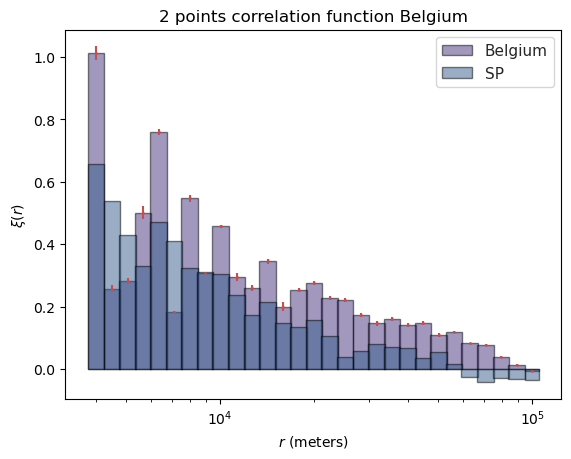

0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 992473
min DD 36
maxRR 288377
minRR 10
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 992473
min DD 36
maxRR 288100
minRR 21
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 992473
min DD 36
maxRR 287194
minRR 20
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 1009812
min DD 16
maxRR 286748
minRR 24
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 1009812
min DD 16
maxRR 288459
minRR 14
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
norm

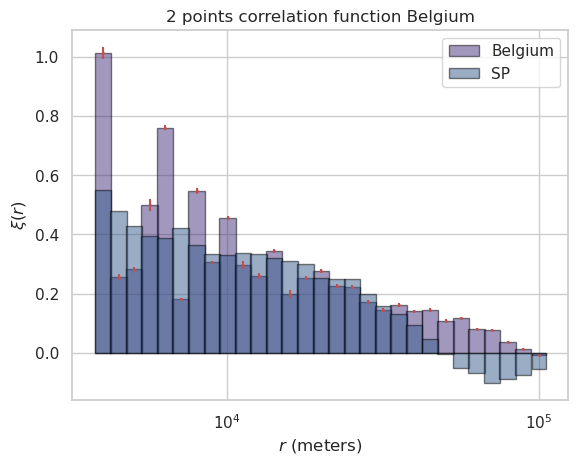

0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 972310
min DD 30
maxRR 288071
minRR 34
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 972310
min DD 30
maxRR 286170
minRR 35
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 972310
min DD 30
maxRR 288217
minRR 37
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 988023
min DD 29
maxRR 286700
minRR 23
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 988023
min DD 29
maxRR 287169
minRR 3
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normali

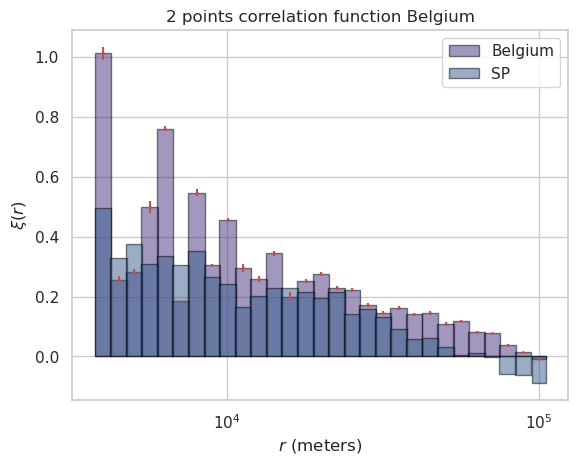

0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 967304
min DD 79
maxRR 285454
minRR 31
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 967304
min DD 79
maxRR 287907
minRR 29
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 967304
min DD 79
maxRR 287155
minRR 25
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 973283
min DD 118
maxRR 288044
minRR 29
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 973283
min DD 118
maxRR 288288
minRR 39
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
norm

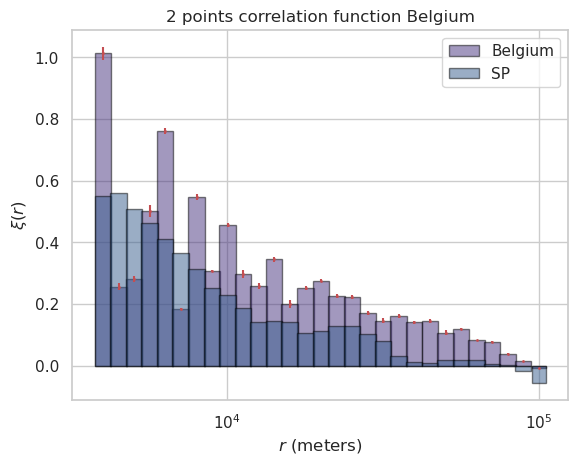

0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 975657
min DD 135
maxRR 286996
minRR 29
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 975657
min DD 135
maxRR 286825
minRR 59
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 975657
min DD 135
maxRR 286600
minRR 26
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 1010353
min DD 116
maxRR 287693
minRR 26
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 1010353
min DD 116
maxRR 286050
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31

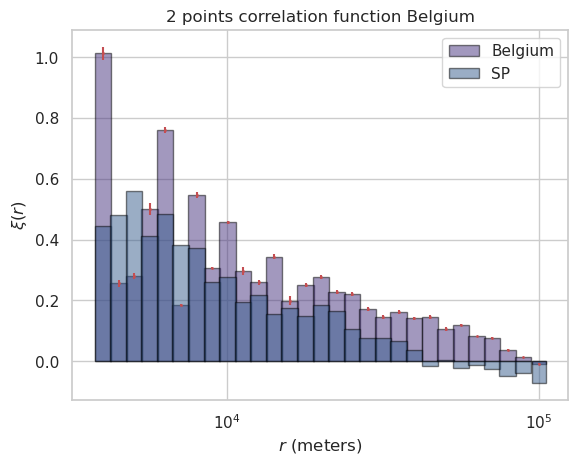

In [11]:
iteration_pure_SP = 5 #number of try to set the basis of the SOneira-Peebles 2pcf
number_of_try_for_each_parameter = 5 #number of generated 2pcf SP+random by set of paraemters to compare with the reference

save_dist,save_L,save_random = find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter,iteration_pure_SP)

## save the generative parameters

In [12]:
save_dir =  Path.cwd().parent /Path(f"out/fitted_parameters_SP/{name}")

dico_results["iteration_pure_SP"] = iteration_pure_SP
dico_results["number_of_try_for_each_parameter"] = number_of_try_for_each_parameter
dico_results["euclidean_distance_generated_empirical"] = save_dist
dico_results["list_L_generated"] = save_L
dico_results["list_l_cluster"] = l_cluster
dico_results["lsit_number_random_generated"] = save_random
slp.save_results(save_dir,dico_results)

In [13]:
dico_results

{'r_edges': array([  3579.20107024,   4014.72258873,   4503.23889274,   5051.19845192,
          5665.83439352,   6355.25998044,   7128.57570726,   7995.98942774,
          8968.95109964,  10060.30392545,  11284.45388408,  12657.55989139,
         14197.74709967,  15925.34615169,  17863.16154745,  20036.77266609,
         22474.87141659,  25209.64097412,  28277.18060157,  31717.98216383,
         35577.46462494,  39906.57358342,  44762.45375992,  50209.20331385,
         56318.71994624,  63171.64995741,  70858.45278712,  79480.59508925,
         89151.89010293, 100000.        ]),
 'xi': array([[ 0.20426935,  0.98394861,  0.24638902,  0.26794562,  0.50842757,
          0.74822644,  0.1809176 ,  0.53783681,  0.30754255,  0.44927189,
          0.2832859 ,  0.24873806,  0.33417227,  0.18383534,  0.24986574,
          0.26823848,  0.21844225,  0.21318139,  0.16328831,  0.13507687,
          0.15216161,  0.13574661,  0.13696144,  0.09909736,  0.11435199,
          0.08179384,  0.07894132,  0

# Compute the Kullback Leibler divergence 

In [30]:
def compare_log_distribution(n_short,n_iteration,l,eta,L,R,gdf_edge,crs,number_point,random_point,erase_nodes,k,rmax,scale,nbins,country_distribution,show_histplot=False):
    KL_distanceSP = 1000
    KL_distance_random =1000
    positionSP,position_random = 0,0
    r_bins = np.logspace(np.log10(100),np.log10(np.max(country_distribution)+1),nbins)
    country_distribution_log = mtpc.binning_data(country_distribution,nbins,r_bins)
    save_random = 0
    save_SP = 0
    l_inter_SP = []
    l_inter_random = []
    l_inter_SP_short = []
    l_inter_random_short = []
    for i in range(n_iteration):
        position = check_inside(l,eta,L,R,gdf_edge,erase_nodes)
        d = {}
        d["x"] = position.T[0]
        d["y"] = position.T[1]
        #df = pd.DataFrame((position))
        gdf = gpd.GeoDataFrame(
              d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
        gdf_random_square = gdf_edge.sample_points(random_point)
        gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
        gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
        #print(len(gdf))
        l_index = [i for i in range(len(gdf))]
        to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
        gdf.drop(to_drop, inplace=True)
       # print(len(gdf))
        position = gdf.get_coordinates().values
        r_edge,l_xi_SP = make_2pcf_for_model(position,crs,0,gdf_edge,rmax)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
        #ax = gdf_edge.plot()
        #gdf.plot(ax=ax,color="red",markersize=0.5)
        #plt.show()
        gdf_projected_random= mtpc.generate_random_point(gdf_edge,number_point,crs,check_gpd=True)
        #r_edges_random_SP,l_xi_random_SP = mtpc.PCF_with_variance(gdf_projected_random,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins)
        distance_distribution_random_nobin = mtpc.compute_DD(gdf_projected_random)
        distance_distribution_SP_nobin = mtpc.compute_DD(gdf)
        distance_distribution_SP = mtpc.binning_data(distance_distribution_SP_nobin,nbins,r_bins)[0:nbins]
        distance_distribution_random = mtpc.binning_data(distance_distribution_random_nobin,nbins,r_bins)[0:nbins]

        distance_distribution_random = distance_distribution_random/np.sum(distance_distribution_random)
        distance_distribution_SP = distance_distribution_SP/np.sum(distance_distribution_SP)
        KL_distanceSP_inter = entropy(country_distribution_log[0:n_short]+1,distance_distribution_SP[0:n_short]+1)
        KL_distance_random_inter = entropy(country_distribution_log[0:n_short]+1,distance_distribution_random[0:n_short]+1)
        l_inter_SP_short.append(KL_distanceSP_inter)
        l_inter_random_short.append(KL_distance_random_inter)
        KL_distanceSP_inter = entropy(country_distribution_log+1,distance_distribution_SP+1)
        KL_distance_random_inter = entropy(country_distribution_log+1,distance_distribution_random+1)
        l_inter_SP.append(KL_distanceSP_inter) 
        l_inter_random.append(KL_distance_random_inter)
        if show_histplot:
            stat="density"
            sns.histplot(country_distribution,bins=nbins,stat="density",label="original",legend=True,log_scale=True)
            sns.histplot(distance_distribution_SP_nobin,bins=nbins,stat="density",label="SP",legend=True,log_scale=True)
            sns.histplot(distance_distribution_random_nobin,bins=nbins,stat="density",label="random",legend=True,log_scale=True)
            plt.yscale("log")
            plt.legend()
            plt.show()
    return l_inter_SP,l_inter_random,l_inter_SP_short,l_inter_random_short

In [2]:
n_iteration = 50 # number of distribution to make
n_short = 25 # number of bins of small range to consider in KL_short
show_histplot = False
L = save_L[np.argmin(save_dist)] #np.argmin(save_dist)
eta = l_cluster[np.argmin(save_dist)]
l = eta**(1/(2-gamma))
random_point = save_random[np.argmin(save_dist)]
# KLSP,KLrandom
KLSP,KLrandom,KLSP_short,KLrandom_short = compare_log_distribution(n_short,n_iteration,l,eta,L,R,gdf_edge,crs,N,random_point,erase_nodes,k,rmax,scale,nbins,country_distribution,show_histplot)

NameError: name 'save_L' is not defined

In [1]:
plt.boxplot([KLrandom,KLSP],labels=["random","Soneira-Peebles+random"])
plt.ylabel("Kullback-Leibler divergence")
plt.savefig(plot_dir / ("KL_"+name), format="png",transparent=True)
from scipy.stats import ttest_ind
print(ttest_ind(KLrandom,KLSP,equal_var=False))

NameError: name 'plt' is not defined

TtestResult(statistic=19.509235832048613, pvalue=3.893905583681703e-30, df=70.53111213450393)


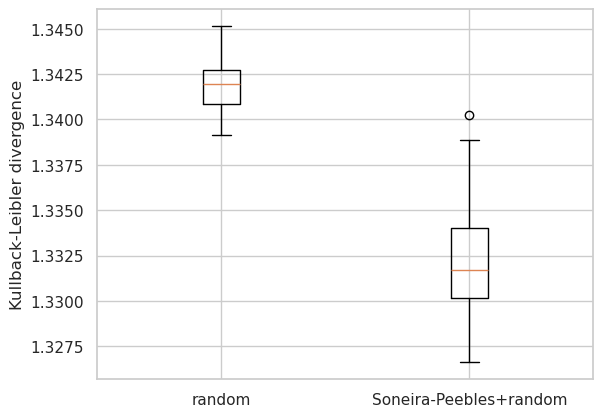

In [31]:
plt.boxplot([KLrandom_short,KLSP_short],labels=["random","Soneira-Peebles+random"])
plt.ylabel("Kullback-Leibler divergence")
plt.savefig(plot_dir / ("KL_short_"+name), format="png",transparent=True)
print(ttest_ind(KLrandom_short,KLSP_short,equal_var=False))

# Save the fitted parameters

In [33]:
L = save_L[np.argmin(save_dist)] #np.argmin(save_dist)
eta = l_cluster[np.argmin(save_dist)]
l = eta**(1/(2-gamma))
random_point = save_random[np.argmin(save_dist)]
dico_results["save_dist"] = save_dist
dico_results["L"] = save_L
dico_results["eta"] = l_cluster
dico_results["save_random"] = save_random
slp.save_results(save_dir,dico_results)

0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 280738
min DD 39
maxRR 288110
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 280738
min DD 39
maxRR 287419
minRR 32
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 280738
min DD 39
maxRR 289141
minRR 51
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


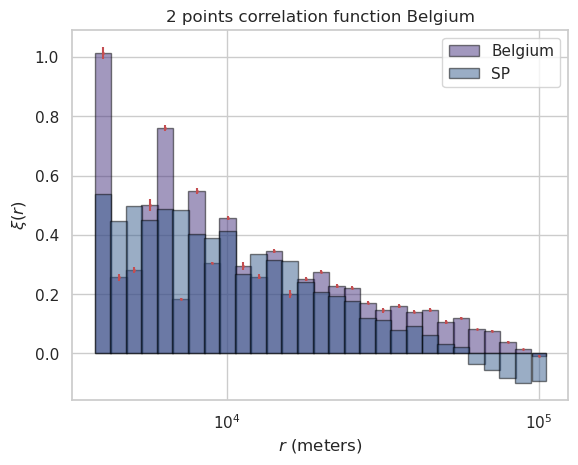

In [42]:
position = check_inside(l,eta,L,R,gdf_edge)
r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax)
plot_two_2pcf(r_edges,l_xi,l_xi_random_SP)

In [37]:
print(save_L[np.argmin(save_dist)],l_cluster[np.argmin(save_dist)])

4 4


[1.1798847737494849,
 1.0382155380166718,
 1.0014556722997912,
 1.0799073627906017,
 0.920082085496158]

# Plot an example of the point sprinkle with fitted parameters on the map

256
820


<Axes: >

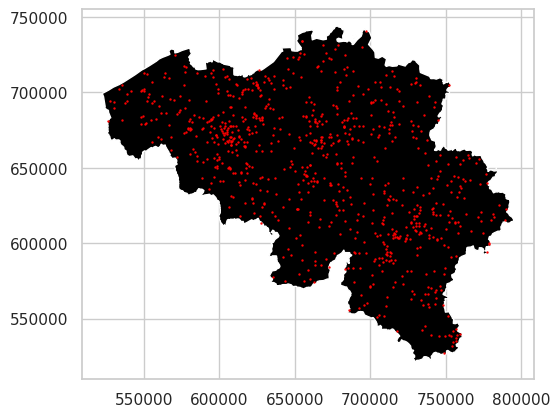

In [39]:
position = check_inside(l,eta,L,R,gdf_edge)
d = {}
d["x"] = position.T[0]
d["y"] = position.T[1]
gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
print(len(gdf))
gdf_random_square = gdf_edge.sample_points(random_point)
gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
l_index = [i for i in range(len(gdf))]
to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
gdf.drop(to_drop, inplace=True)
print(len(gdf))
convex_hull_polygon = gdf.union_all()
polygon = convex_hull_polygon.convex_hull
geoserie = gpd.GeoSeries(polygon)
squares_gdf=gpd.GeoDataFrame({'geometry': geoserie, 'df':[1]},crs=crs)
fig,ax = plt.subplots()
#squares_gdf.plot(ax=ax)
gdf_edge.plot(ax=ax,color="black")
gdf.plot(ax=ax,color="red",markersize=0.5)

In [ ]:
position = check_inside(l,eta,L,R,gdf_edge)
d = {}
d["x"] = position.T[0]
d["y"] = position.T[1]
gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
print(len(gdf))
gdf_random_square = gdf_edge.sample_points(random_point)
gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
l_index = [i for i in range(len(gdf))]
to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
gdf.drop(to_drop, inplace=True)
print(len(gdf))
convex_hull_polygon = gdf.union_all()
polygon = convex_hull_polygon.convex_hull
geoserie = gpd.GeoSeries(polygon)
squares_gdf=gpd.GeoDataFrame({'geometry': geoserie, 'df':[1]},crs=crs)
fig,ax = plt.subplots()
#squares_gdf.plot(ax=ax)
gdf_edge.plot(ax=ax,color="black")
gdf.plot(ax=ax,color="red",markersize=0.5)